## **Figure-1**

In [1]:
import pandas as pd
import polars as pl
from functools import reduce
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import sys
import numpy as np
import matplotlib as mpl
from math import pi


from matplotlib.patches import Rectangle
from matplotlib.patches import FancyBboxPatch
from matplotlib.font_manager import FontProperties

from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


### **Dummy Chromatograms**

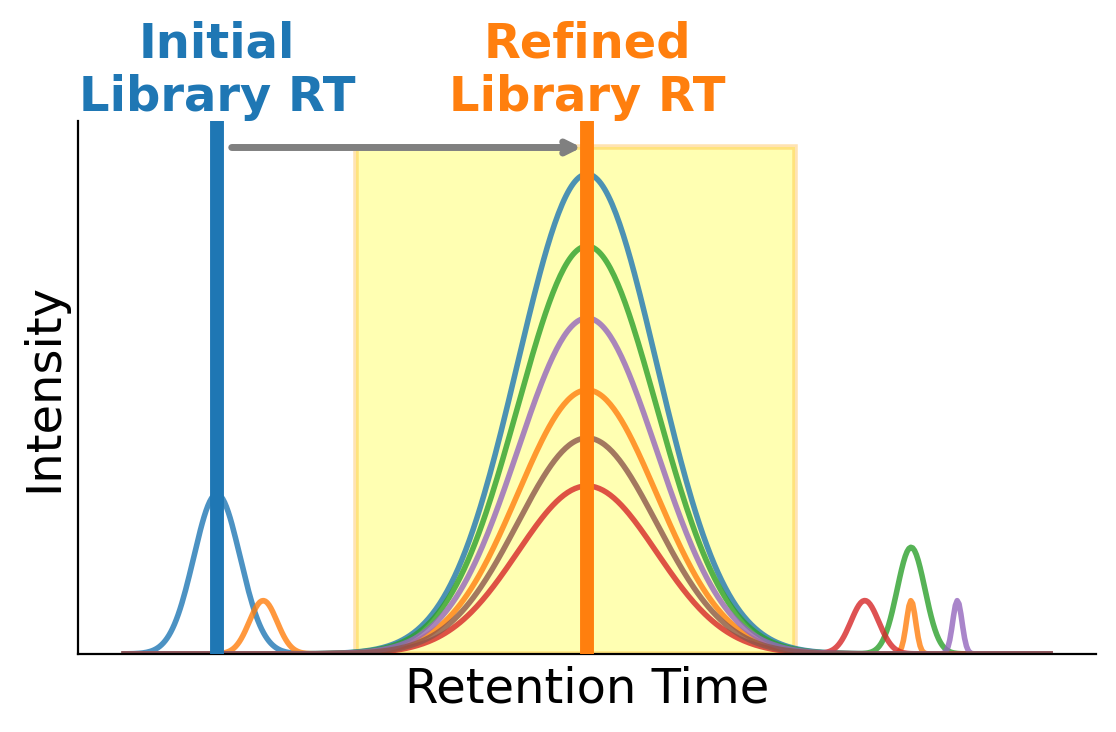

In [3]:
# Retention time axis
rt = np.linspace(40, 60, 500)  # RT range around 50

# Gaussian function
def gaussian(x, mu, sigma, height):
    return height * np.exp(-0.5 * ((x - mu) / sigma)**2)

# Main peak group
mu = 50
sigma = 1.5
heights = np.array([1.0, 0.55, 0.85, 0.35, 0.7, 0.45]) * 0.9

# Colors - consistent with final version
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(6, 4), dpi=200)
    
# --- Main transitions ---
intensities = []
for h, c in zip(heights, colors):
    intensities.append(gaussian(rt, mu, sigma, h))
    
intensities[0] += gaussian(rt, 42, 0.5, 0.3)
intensities[1] += gaussian(rt, 43, 0.3, 0.1)
intensities[1] += gaussian(rt, 57, 0.1, 0.1)
intensities[2] += gaussian(rt, 57, 0.3, 0.2)
intensities[3] += gaussian(rt, 56, 0.3, 0.1)
intensities[4] += gaussian(rt, 58, 0.1, 0.1)

for c, i in zip(colors, intensities):
    plt.plot(rt, i, color=c, lw=2.0, alpha=0.8, zorder=2)

# --- Add highlighting box around main peak group ---
ax = plt.gca()
# Define box boundaries around the main peak group
box_left = 45
box_right = 54.5
box_bottom = 0
box_top = 0.95

# Create rectangle patch with yellow fill
highlight_box = Rectangle((box_left, box_bottom), 
                         box_right - box_left, 
                         box_top - box_bottom,
                         linewidth=2, 
                         edgecolor='orange', 
                         facecolor='yellow', 
                         alpha=0.3,
                         zorder=1)  # Behind the traces
ax.add_patch(highlight_box)

# --- RT markers ---
plt.axvline(42, color="tab:blue", ls="-", alpha=1, zorder=5, lw=5)   # Library RT
plt.text(42, 1.0, "Initial\nLibrary RT", color="tab:blue", ha="center", va="bottom", fontsize='xx-large', fontweight='bold')
plt.axvline(50, color="tab:orange", ls="-", alpha=1, zorder=5, lw=5)   # Library RT
plt.text(50, 1.0, "Refined\nLibrary RT", color="tab:orange", ha="center", va="bottom", fontsize='xx-large', fontweight='bold')
plt.annotate('', (50, 0.95), xytext=(42.2, 0.95), arrowprops=dict(arrowstyle='->',color='grey', lw=2.5))

# Axis labels
plt.xlabel("Retention Time", fontsize='xx-large')
plt.ylabel("Intensity", fontsize='xx-large')
ax.annotate

# Only bottom + left spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, 1)

plt.tight_layout()

# Hide x-axis ticks and labels
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Hide y-axis ticks and labels
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

plt.show()

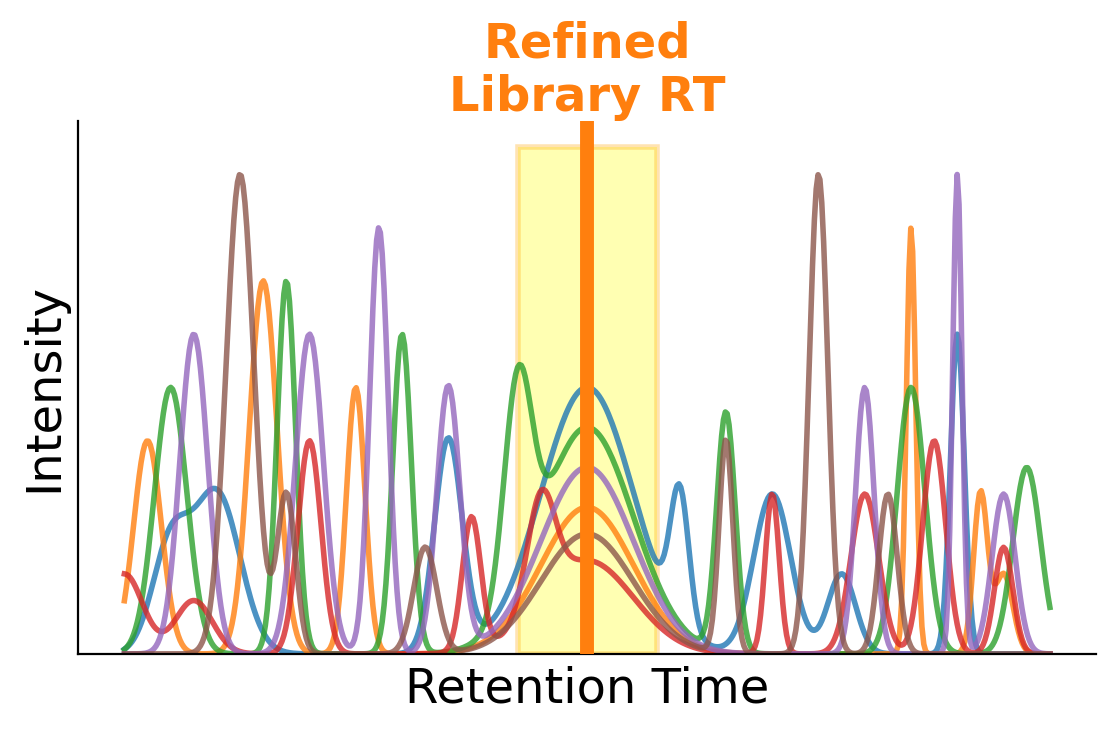

In [4]:
# Retention time axis
rt = np.linspace(40, 60, 500)  # RT range around 50

# Gaussian function
def gaussian(x, mu, sigma, height):
    return height * np.exp(-0.5 * ((x - mu) / sigma)**2)

# Main peak group
mu = 50
sigma = 1
heights = np.array([1.0, 0.55, 0.85, 0.35, 0.7, 0.45]) * 0.5

# Colors - darker colors for better contrast with yellow highlight
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(6, 4), dpi=200)

# --- Main transitions ---
intensities = []
for h, c in zip(heights, colors):
    intensities.append(gaussian(rt, mu, sigma, h))

# --- Manually defined interference peaks ---
# Transition 0
intensities[0] += gaussian(rt, 42, 0.5, 0.3)
intensities[0] += gaussian(rt, 55.5, 0.3, 0.15)

# Transition 1
intensities[1] += gaussian(rt, 43, 0.3, 0.7)
intensities[1] += gaussian(rt, 57, 0.1, 0.8)
intensities[1] += gaussian(rt, 59, 0.2, 0.15)

# Transition 2
intensities[2] += gaussian(rt, 46, 0.2, 0.6)
intensities[2] += gaussian(rt, 57, 0.3, 0.5)

# Transition 3
intensities[3] += gaussian(rt, 41.5, 0.4, 0.1)
intensities[3] += gaussian(rt, 56, 0.3, 0.3)
intensities[3] += gaussian(rt, 59, 0.2, 0.2)

# Transition 4
intensities[4] += gaussian(rt, 44, 0.3, 0.6)
intensities[4] += gaussian(rt, 58, 0.1, 0.9)

# Transition 5
intensities[5] += gaussian(rt, 42.5, 0.3, 0.9)
intensities[5] += gaussian(rt, 55, 0.2, 0.9)

# --- Add many more interference peaks ---
# Transition 0 - additional interferences
intensities[0] += gaussian(rt, 41, 0.4, 0.2)
intensities[0] += gaussian(rt, 47, 0.3, 0.4)
intensities[0] += gaussian(rt, 52, 0.2, 0.25)
intensities[0] += gaussian(rt, 54, 0.4, 0.3)
intensities[0] += gaussian(rt, 58, 0.15, 0.6)

# Transition 1 - additional interferences
intensities[1] += gaussian(rt, 40.5, 0.3, 0.4)
intensities[1] += gaussian(rt, 45, 0.2, 0.5)
intensities[1] += gaussian(rt, 58.5, 0.15, 0.3)

# Transition 2 - additional interferences
intensities[2] += gaussian(rt, 41, 0.35, 0.5)
intensities[2] += gaussian(rt, 43.5, 0.2, 0.7)
intensities[2] += gaussian(rt, 48.5, 0.3, 0.4)
intensities[2] += gaussian(rt, 53, 0.2, 0.45)
intensities[2] += gaussian(rt, 59.5, 0.3, 0.35)

# Transition 3 - additional interferences
intensities[3] += gaussian(rt, 40, 0.4, 0.15)
intensities[3] += gaussian(rt, 44, 0.25, 0.4)
intensities[3] += gaussian(rt, 47.5, 0.2, 0.25)
intensities[3] += gaussian(rt, 49, 0.3, 0.2)
intensities[3] += gaussian(rt, 54, 0.15, 0.3)
intensities[3] += gaussian(rt, 57.5, 0.25, 0.4)

# Transition 4 - additional interferences
intensities[4] += gaussian(rt, 41.5, 0.3, 0.6)
intensities[4] += gaussian(rt, 45.5, 0.2, 0.8)
intensities[4] += gaussian(rt, 47, 0.25, 0.5)
intensities[4] += gaussian(rt, 56, 0.2, 0.5)
intensities[4] += gaussian(rt, 59, 0.25, 0.3)

# Transition 5 - reduced interferences to keep main peak clear
intensities[5] += gaussian(rt, 43.5, 0.2, 0.3)
intensities[5] += gaussian(rt, 46.5, 0.25, 0.2)
intensities[5] += gaussian(rt, 53, 0.15, 0.4)
intensities[5] += gaussian(rt, 56.5, 0.2, 0.3)

# --- Plot transitions ---
for c, i in zip(colors, intensities):
    plt.plot(rt, i, color=c, lw=2.0, alpha=0.8, zorder=2)

# --- Add highlighting box around main peak group ---
ax = plt.gca()
# Define box boundaries around the main peak group
box_left = 48.5
box_right = 51.5
box_bottom = 0
box_top = 0.95

# Create rectangle patch with yellow fill
highlight_box = Rectangle((box_left, box_bottom), 
                         box_right - box_left, 
                         box_top - box_bottom,
                         linewidth=2, 
                         edgecolor='orange', 
                         facecolor='yellow', 
                         alpha=0.3,
                         zorder=1)  # Behind the traces
ax.add_patch(highlight_box)


# --- RT markers ---
plt.axvline(50, color="tab:orange", ls="-", alpha=1, zorder=5, lw=5)   # Library RT
plt.text(50, 1.0, "Refined\nLibrary RT", color="tab:orange", ha="center", va="bottom", fontsize='xx-large', fontweight='bold')

# Axis labels
plt.xlabel("Retention Time", fontsize='xx-large')
plt.ylabel("Intensity", fontsize='xx-large')

# Only bottom + left spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, 1)

plt.tight_layout()
# Hide x-axis ticks and labels
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Hide y-axis ticks and labels
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

plt.show()

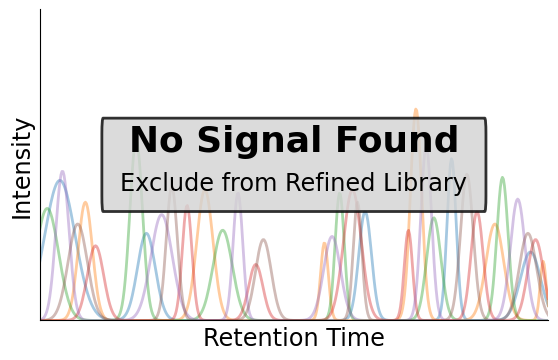

In [5]:
# Retention time axis
rt = np.linspace(40, 60, 500)  # RT range around 50

# Gaussian function
def gaussian(x, mu, sigma, height):
    return height * np.exp(-0.5 * ((x - mu) / sigma)**2)

# Colors - darker colors for better contrast with yellow highlight
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(6, 4))

# --- Start with baseline noise only (no main peaks) ---
intensities = []
for i in range(6):
    intensities.append(np.zeros_like(rt))

# --- Add only interference/noise peaks (completely different from example) ---
# Transition 0 - random background peaks
intensities[0] += gaussian(rt, 40.8, 0.6, 0.45)
intensities[0] += gaussian(rt, 44.2, 0.35, 0.28)
intensities[0] += gaussian(rt, 52.8, 0.25, 0.35)
intensities[0] += gaussian(rt, 56.2, 0.18, 0.52)
intensities[0] += gaussian(rt, 59.3, 0.4, 0.22)

# Transition 1 - random background peaks
intensities[1] += gaussian(rt, 41.8, 0.28, 0.38)
intensities[1] += gaussian(rt, 46.5, 0.32, 0.42)
intensities[1] += gaussian(rt, 51.2, 0.15, 0.25)
intensities[1] += gaussian(rt, 54.8, 0.22, 0.68)
intensities[1] += gaussian(rt, 57.9, 0.35, 0.31)
intensities[1] += gaussian(rt, 59.8, 0.12, 0.19)

# Transition 2 - random background peaks
intensities[2] += gaussian(rt, 40.3, 0.45, 0.36)
intensities[2] += gaussian(rt, 43.8, 0.25, 0.58)
intensities[2] += gaussian(rt, 47.2, 0.38, 0.29)
intensities[2] += gaussian(rt, 51.8, 0.18, 0.41)
intensities[2] += gaussian(rt, 55.5, 0.28, 0.33)
intensities[2] += gaussian(rt, 58.2, 0.22, 0.46)

# Transition 3 - random background peaks
intensities[3] += gaussian(rt, 42.2, 0.32, 0.24)
intensities[3] += gaussian(rt, 45.8, 0.19, 0.37)
intensities[3] += gaussian(rt, 48.5, 0.28, 0.18)
intensities[3] += gaussian(rt, 52.3, 0.35, 0.42)
intensities[3] += gaussian(rt, 54.5, 0.16, 0.29)
intensities[3] += gaussian(rt, 57.2, 0.24, 0.35)
intensities[3] += gaussian(rt, 59.5, 0.31, 0.26)

# Transition 4 - random background peaks
intensities[4] += gaussian(rt, 40.9, 0.26, 0.48)
intensities[4] += gaussian(rt, 44.8, 0.42, 0.34)
intensities[4] += gaussian(rt, 47.8, 0.19, 0.41)
intensities[4] += gaussian(rt, 51.5, 0.33, 0.27)
intensities[4] += gaussian(rt, 55.2, 0.21, 0.56)
intensities[4] += gaussian(rt, 58.8, 0.29, 0.39)

# Transition 5 - random background peaks
intensities[5] += gaussian(rt, 41.5, 0.38, 0.31)
intensities[5] += gaussian(rt, 45.2, 0.22, 0.43)
intensities[5] += gaussian(rt, 48.8, 0.31, 0.26)
intensities[5] += gaussian(rt, 52.5, 0.17, 0.38)
intensities[5] += gaussian(rt, 56.8, 0.25, 0.47)
intensities[5] += gaussian(rt, 59.2, 0.34, 0.28)

# --- Plot transitions ---
for c, i in zip(colors, intensities):
    plt.plot(rt, i, color=c, lw=2.0, alpha=0.4, zorder=2)

# --- Add highlighting box around where analyte should be (but isn't) ---
ax = plt.gca()
# Define box boundaries around the expected analyte region
box_left = 48.5
box_right = 51.5
box_bottom = 0
box_top = 0.95


#plt.text(50, 0.5, "No Signal Found", color="black", ha="center", va="bottom", fontsize='xx-large')
#ax.text(50, 0.5, "No Signal Found\nExclude from Refined Library", color="black", ha="center", va="bottom", fontsize='xx-large', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", edgecolor="black", linewidth=2))

# The position of the text block and box
x_pos = 50
y_pos = 0.5

# Create a FancyBboxPatch to act as the background box
box_style = "round,pad=0.05"
box_facecolor = "lightgray"
box_edgecolor = "black"
box_linewidth = 2
box_width = 15  # You may need to adjust this to fit your text
box_height = 0.2 # You may need to adjust this to fit your text

# Calculate the bottom-left corner of the box
box_x = x_pos - (box_width / 2)
box_y = y_pos - (box_height / 2)

# Add the box to the plot first, so the text appears on top
ax.add_patch(
    FancyBboxPatch(
        (box_x, box_y),
        box_width,
        box_height,
        boxstyle=box_style,
        fc=box_facecolor,
        ec=box_edgecolor,
        lw=box_linewidth,
        alpha=0.8,
        
        zorder=100 # Ensure the patch is in the background
    )
)

# First line: bold and larger font size
xx_large = FontProperties(size='xx-large')
xxx_large = xx_large.copy()
xxx_large.set_size(xxx_large.get_size_in_points() * 1.5)  # scale up
ax.text(
    x_pos,
    y_pos + 0.02, # Position above the center
    "No Signal Found",
    color="black",
    ha="center",
    va="bottom",
    fontproperties=xxx_large,
    fontweight='bold',
    zorder=200 # Ensure the text is on top of the patch
)

# Second line: smaller font size
ax.text(
    x_pos,
    y_pos - 0.02, # Position below the center
    "Exclude from Refined Library",
    color="black",
    ha="center",
    va="top",
    fontsize='xx-large',
    zorder=200 # Ensure the text is on top of the patch
)

# Axis labels
plt.xlabel("Retention Time", fontsize='xx-large')
plt.ylabel("Intensity", fontsize='xx-large')

# Only bottom + left spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, 1)

plt.tight_layout()
# Hide x-axis ticks and labels
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Hide y-axis ticks and labels
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
ax.set_xlim(40, 60)
plt.show()

---

---

## **1. Peptide Characteristics Metrics**

In [6]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman, 2014',
             diatracer='Direct',
             refined='Reconstructed',
             refined_diatracer='Direct Reconstruction')

metrics = {
    "char": "Peptide\nProperty\nPrecision",
    "sample": "Sample\nConservation",
    "concord": "Library-Sample\nConcordance",
    'coverage':'Sample\nScope', # library "scope" of the sample less of a negative connotation if it decreases compared to sample
    'ids':'Identification\nRates',
}



#### **Load Data**

In [8]:
osw = {}

# Diatracer data - used as ground truth for peptide property precision
osw[names['diatracer']] = getPrecursorDf_Characteristics("../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")

# Bruker data
osw[names['bruker']] = getPrecursorDf_Characteristics("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")

# Panhuman data
osw[names['panhuman']] = getPrecursorDf_Characteristics_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet")

# Experimental data
osw[names['exp']] = getPrecursorDf_Characteristics("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")

# Silico data
osw[names['silico']] = getPrecursorDf_Characteristics_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet")


osw = pd.concat(osw).reset_index(names=['Library', 'i']).drop(columns='i')

../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/precursors_features.parquet
../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-2

### **Fragment Ion Intensities OSW**

This is created in Figure-1-Helper

In [9]:
osw_frag_intens = pd.read_csv("fragment-ion-intensity-std.tsv", sep='\t')

#### **Compute Metrics**

To compute the metrics, take the standard deviation across `FEATURE_MS2.DELTA_IM` `FEATURE.DELTA_RT` and `residual`, normalize to 1.0 (diaTracer is expected to be the best for all of them) and then take the average. 

To better illustrate my point, I normalize so that the experimental library is 1. Since the direct library is much better, just floor this value to 1. 

In [10]:
im_std = osw[['Library', 'FEATURE_MS2.DELTA_IM']].groupby('Library').std()
im_std['Ion Mobility Accuracy'] = min(im_std['FEATURE_MS2.DELTA_IM'])  / im_std['FEATURE_MS2.DELTA_IM']

rt_std = osw[['Library', 'FEATURE.DELTA_RT']].groupby('Library').std()
rt_std['Retention Time Accuracy'] = min(rt_std['FEATURE.DELTA_RT']) / rt_std['FEATURE.DELTA_RT']

frag_std = osw_frag_intens[['Library', 'residual']].groupby('Library').std()
frag_std['Relative Fragment Ion Intensity Accuracy'] = min(frag_std['residual']) / frag_std['residual']

properties = pd.concat([im_std, rt_std, frag_std], axis=1)
properties[metrics['char']] = (properties['Ion Mobility Accuracy'] + properties['Retention Time Accuracy'] + properties['Relative Fragment Ion Intensity Accuracy']) / 3



properties = properties[properties.index != 'Direct']

---

## **2. Library-Sample Concordance** 

In [11]:
libs = {}

libs[names['bruker']] = getCompressedTSVLibPrecursors("../../data/BrukerLibrary/_ip2_ip2_data_paser_spectral_library__Bruker_Human.tsv.zst")
libs[names['silico']] = getCompressedTSVLibPrecursors("../../results/PeptDeep-NoMods-In-Silico-Library-Generation/2025-06-10-in-silico-lib-no-mods_fix_mods_filtered.tsv.zst")
libs[names['exp']] = getCompressedTSVLibPrecursors("../../results/K562-Library-Generation/library.tsv", compression=None)
libs[names['panhuman']] = getCompressedTSVLibPrecursors("../../results/PanHuman-Library-Creation/phl004_s32_imAppended_fixed_diann.tsv", compression=None)

../../data/BrukerLibrary/_ip2_ip2_data_paser_spectral_library__Bruker_Human.tsv.zst
../../results/PeptDeep-NoMods-In-Silico-Library-Generation/2025-06-10-in-silico-lib-no-mods_fix_mods_filtered.tsv.zst
../../results/K562-Library-Generation/library.tsv
../../results/PanHuman-Library-Creation/phl004_s32_imAppended_fixed_diann.tsv


Estimate number of sample precursors based on the experimental library. 

In [12]:
pi0 = 0.177 # this is taken from pyprophet_XGB pyprophet report

number_sample_precursors = len(libs[names['exp']]) * (1-pi0)

sample_lib_concordance = {}
for k, v in libs.items():
    sample_lib_concordance[k] = abs(len(v) - number_sample_precursors)

sample_lib_concordance = pd.DataFrame(pd.Series(sample_lib_concordance, name='Concordance'))

sample_lib_concordance[metrics['concord']] = min(sample_lib_concordance['Concordance']) / sample_lib_concordance['Concordance']

sample_lib_concordance

,Concordance,Library-Sample\nConcordance
"timsTOF, 2024",451485.853,0.058174
in-silico,6284592.853,0.004179
Experimental,26264.853,1.000000
"PanHuman, 2014",82439.853,0.318594


---

## **3. Sample Usage**

This metric is just kind of made up, eveyrthing requires no sample usage except for the experimental library. 

In [13]:
sample_usage = {
    names["exp"]: 0.2,
    names['panhuman']: 1.0,
    names['bruker']: 1.0,
    names['silico']: 1.0}

sample_usage = pd.DataFrame(pd.Series(sample_usage, name=metrics['sample']))

## **4. Sample Scope**

This metric aims to estimate the sample coverage. Assumes that the experimental library is 1.0, estimate the other libraries relative to that. This is done by determining the proportion of the experimental library which is contained in the other libraries. 

Clear than timsTOF panHuman and dia in silico are relatively high while the direct and panHuman are much lower. 

In [14]:
sample_coverage = {}
for i in libs.keys():
    sample_coverage[i] = 1 - len(libs['Experimental'].difference(libs[i])) / len(libs['Experimental'])

sample_coverage = pd.Series(sample_coverage, name=metrics['coverage'])

---

## **5. Lengths of Libraries** 

Taken from Table 1. 

In [21]:
lib_lengths = {
    "Library": [
        "Experimental",
        "in-silico",
        "PanHuman, 2014",
        "timsTOF, 2024",
    ],
    "Precursors": [
        148_389,
        6_406_717,
        204_564,
        573_610,
    ],
    "Proteins": [
        8_206,
        20_381,
        11_378,
        13_002,
    ]
}
lib_lengths = pd.DataFrame(lib_lengths, index=lib_lengths['Library']).drop(columns=['Library'])

## **6. Plot**

In [22]:
df = pd.concat([sample_usage[metrics['sample']], properties[metrics['char']], sample_lib_concordance[metrics['concord']], sample_coverage], axis=1)

In [17]:
df

,Sample\nConservation,Peptide\nProperty\nPrecision,Library-Sample\nConcordance,Sample\nScope
Experimental,0.2,0.464043,1.000000,1.000000
"PanHuman, 2014",1.0,0.309951,0.318594,0.524769
"timsTOF, 2024",1.0,0.435507,0.058174,0.782942
in-silico,1.0,0.446264,0.004179,0.873926


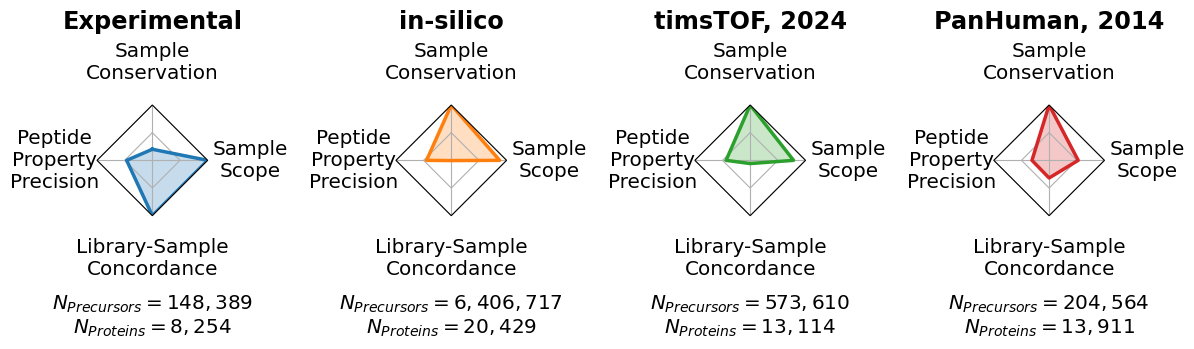

In [18]:
colors = dict(
    exp="#1f77b4",
    silico="#ff7f0e",
    bruker="#2ca02c",
    panhuman="#d62728",
    refined="black",
)


def radar_factory(num_vars, frame='circle'):
    """
    Create a radar chart with `num_vars` Axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle', 'polygon'}
        Shape of frame surrounding Axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):

        def transform_path_non_affine(self, path):
            # Paths with non-unit interpolation steps correspond to gridlines,
            # in which case we force interpolation (to defeat PolarTransform's
            # autoconversion to circular arcs).
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):

        name = 'radar'
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)
                return {'polar': spine}
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta


# --- 5. Radar Plot Setup ---
categories = list(df.columns)
N = len(categories)

# Use radar_factory to create the theta angles and register projection
theta = radar_factory(N, frame='polygon')

# Create subplots: 2 rows, 2 columns (6 spots total)
fig, axes = plt.subplots(1, 4, subplot_kw=dict(projection='radar'), figsize=(13, 3.5))
axes = axes.flatten()

# Plot first 5 libraries with filled polygons
library_keys = ['exp', 'silico', 'bruker', 'panhuman']
for idx, library_key in enumerate(library_keys):
    ax = axes[idx]
    library_name = names[library_key]
    color = colors[library_key]
    values = df.loc[library_name].tolist()
    
    # Plot line and fill
    ax.plot(theta, values, linewidth=2.5, color=color)
    ax.fill(theta, values, facecolor=color, alpha=0.25)
    
    # Set radial ticks and grid
    ax.set_rgrids([0, 0.5, 1.0], labels=[])
    ax.set_ylim(0, 1.0)

    ax.text(0.5, -0.7, '$N_{{Precursors}} = {:,}$\n$N_{{Proteins}} = {:,}$'.format(
    lib_lengths.loc[names[library_key], 'Precursors'],
    lib_lengths.loc[names[library_key], 'Proteins']), transform=ax.transAxes, ha='center', va='top', fontsize='x-large')
    
    # Set variable labels with better positioning
    ax.set_varlabels(categories)
    # Adjust label distance from plot
    ax.tick_params(pad=20, labelsize='x-large')
    
    # Set title
    ax.set_title(library_name, weight='bold', size='xx-large', position=(0.5, 1.1), pad=60,
                 horizontalalignment='center', verticalalignment='center')
    
plt.subplots_adjust(hspace=0, wspace=1.7, top=0.95, bottom=0.05)
plt.savefig('figure1-lib-radars.png', dpi=300, bbox_inches='tight')

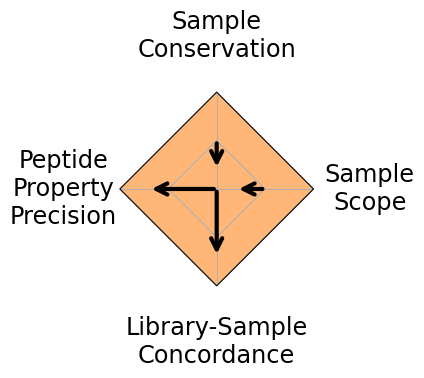

In [19]:
# --- 6. Plot Reconstructed (6th subplot) with arrows ---
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5), subplot_kw=dict(projection='radar'))
ax.set_facecolor('#ff7f0e91')

refined_name = names["refined"]
refined_color = "black"

# Set radial ticks and grid
ax.set_rgrids([0, 0.5, 1.0], labels=[])
ax.set_ylim(0, 1.0)

# Set variable labels
ax.set_varlabels(categories)
ax.tick_params(pad=30, labelsize='xx-large')

#rect = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, 
#                     facecolor='#fffacd', edgecolor='none', zorder=-1)
#ax.add_patch(rect)
# Set title
#ax.set_title(refined_name, weight='bold', size='xx-large', position=(0.5, 1.1), pad=70,
#             horizontalalignment='center', verticalalignment='center')



refined_name = names["refined"]
refined_color = colors["refined"]

# Get refined values
refined_values = [0.5, 0.2, 0.2, 0.5] #df.loc[refined_name].tolist()

# Arrow specifications
arrow_length_up = 0.9
arrow_length_down = 0.3

# Draw arrows for each metric
for i, (angle, value, metric) in enumerate(zip(theta, refined_values, categories)):
    print
    # Determine arrow direction based on metric
    if (metric == metrics["sample"] or metric == metrics['coverage']):  # Sample Conservation - points inward (down)
        r_start = value
        r_end = value - arrow_length_down   
        # Draw arrow
        ax.annotate('', xy=(angle, r_end), xytext=(angle, r_start),
                    arrowprops=dict(arrowstyle='->', lw=3, color=refined_color,
                               mutation_scale=20))
        

    elif (metric == metrics['char'] or metric == metrics['concord']):
        ax.annotate('', xy=(angle, 0.7), xytext=(angle, 0),
                    arrowprops=dict(arrowstyle='->', lw=3, color='black',
                    mutation_scale=20))
        
    
    else:
        pass
    
plt.subplots_adjust(hspace=0, wspace=0.8, top=0.95, bottom=0.05)
plt.show()